<a href="https://www.kaggle.com/code/mdabdulalhasib/practice-for-image-segmentation?scriptVersionId=306387452" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os 
import zipfile

data_root: str = "/kaggle/working/unzipped_data"
train_path: str = "/kaggle/input/competitions/tgs-salt-identification-challenge/train.zip"

os.makedirs(data_root, exist_ok = True)
with zipfile.ZipFile(train_path, "r") as zip_ref:
    zip_ref.extractall(data_root)

In [2]:
from torchvision.io import read_image
from torch.utils.data import Dataset
import torch
import numpy as np
import cv2

class ImgDataset(Dataset):

    def __init__(self, root: str = data_root, indices: list[int] = None, transform = None):

        super(ImgDataset, self).__init__()
        
        inp_imgs = list(sorted(os.listdir(os.path.join(root, "images"))))
        
        self.inp_imgs = inp_imgs
        self.root_images  = os.path.join(root, "images")
        self.root_masks  = os.path.join(root, "masks")
        self.indices = indices
        self.transform = transform
        
    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor] | tuple[np.ndarray , np.ndarray]:

        inner_index: int = self.indices[index]
        inp_img_path = os.path.join(self.root_images, self.inp_imgs[inner_index])
        mask_path = os.path.join(self.root_masks, self.inp_imgs[inner_index])
        
        img: np.ndarray = cv2.cvtColor(cv2.imread(inp_img_path), cv2.COLOR_BGR2RGB)
        mask: np.ndarray = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        mask = (mask > 0).astype(np.float32)
        if self.transform:
            argmt = self.transform(image = img, mask = mask)
            img = argmt["image"]
            mask = argmt["mask"]
        return img, mask

In [3]:
from sklearn.model_selection import train_test_split

all_indices: list[int] = [x for x in range(len(os.listdir(os.path.join(data_root, "images"))))]

train_indices, val_indices, _, _ = train_test_split(
    all_indices,
    all_indices,
    train_size = 0.8,
    test_size = 0.2,
    random_state = 13,
    shuffle = True
)

print(f"Train indices peak: {train_indices[:5]}, size: {len(train_indices)}")
print(f"Validation indices peak: {val_indices[:5]}, size: {len(val_indices)}")

Train indices peak: [182, 237, 207, 1974, 1393], size: 3200
Validation indices peak: [1530, 3571, 3359, 862, 2331], size: 800


In [4]:
TrainingDataset: ImgDataset = ImgDataset(root = data_root, indices = train_indices)
ValidationDataset: ImgDataset = ImgDataset(root = data_root, indices = val_indices)

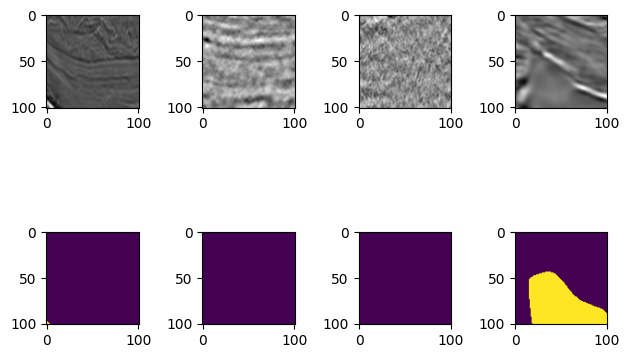

In [5]:
import matplotlib.pyplot as plt
import random 

fig, axes = plt.subplots(2,4)

for j in range(4):
    random_index = random.randint(0 , len(TrainingDataset))
    img, label = TrainingDataset[random_index]
    axes[0, j].imshow(img, cmap = "viridis")
    axes[1, j].imshow(label, cmap = "viridis")
    
plt.tight_layout()
plt.show()

In [6]:
import albumentations as A
import albumentations.pytorch as At
import cv2

train_tf = A.Compose([
    
    A.PadIfNeeded(min_height = 128 , min_width = 128 , border_mode = cv2.BORDER_REFLECT_101),
    A.RandomResizedCrop(size = (128, 128), 
                        scale=(0.85, 1.0), 
                        ratio=(0.9, 1.1), 
                        p = 1.0),
    A.HorizontalFlip(p = 0.5),
    A.VerticalFlip(p = 0.05),

    A.ShiftScaleRotate(
        shift_limit = 0.2,
        scale_limit = 0.2,
        rotate_limit = 15,
        border_mode = cv2.BORDER_REFLECT_101,
        p = 0.4
    ),

    A.OneOf([
    A.ElasticTransform(
        alpha = 1,
        sigma = 50
    ),
    A.GridDistortion(p = 0.5),
    ] , p = 0.4),
    
    A.OneOf([
        A.GaussNoise(std_range = (0.05 , 0.1), p = 0.5),
        A.ISONoise()
    ], p = 0.5),

    A.OneOf([
        A.GaussianBlur(blur_limit = 3),
        A.MotionBlur(blur_limit = 3),
        A.MedianBlur(blur_limit = 3)
    ]),

    A.CoarseDropout(num_holes_range = (1, 16) , hole_height_range = (4, 16), hole_width_range = (4,16), p = 0.5),

    A.Normalize(), # Stay in image net mean and std!
    At.ToTensorV2()
]
)


test_tf = A.Compose([
    A.PadIfNeeded(min_height = 128 , min_width = 128 , border_mode = cv2.BORDER_REFLECT_101),
    A.CenterCrop(height = 128, width = 128),
    A.Normalize(),
    At.ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


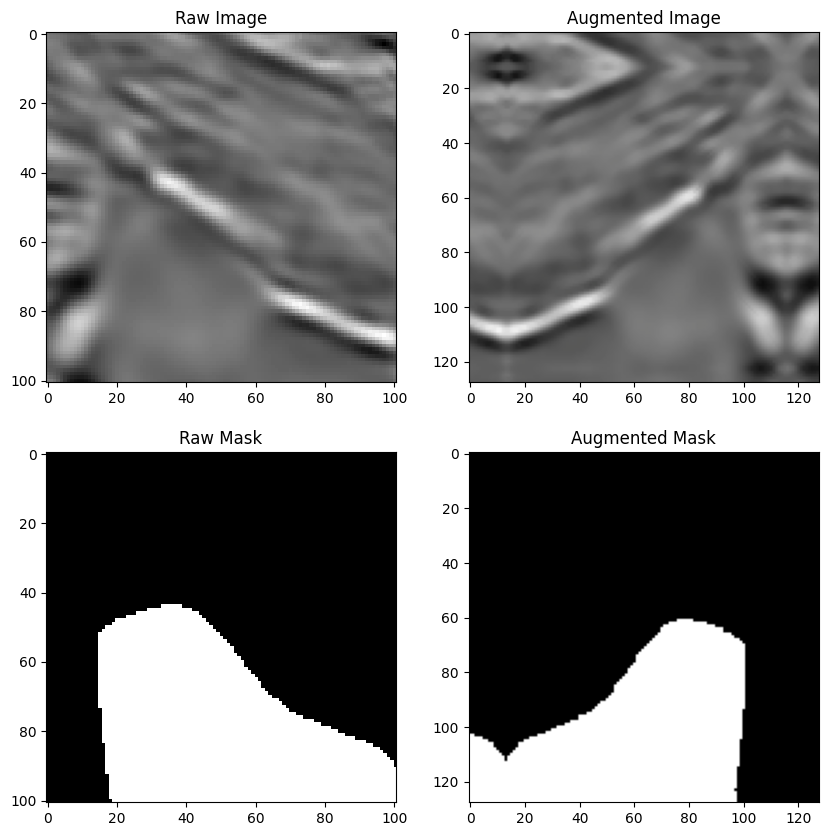

In [7]:
img_raw, mask_raw = TrainingDataset[random_index] 

augmented = train_tf(image=img_raw, mask=mask_raw)
img_aug = augmented['image']
mask_aug = augmented['mask']

def unnormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    
    t = tensor.permute(1, 2, 0) 
    t = t * std + mean
    return torch.clamp(t, 0, 1) 

fig, axes = plt.subplots(2, 2, figsize=(10, 10))


axes[0, 0].imshow(img_raw)
axes[0, 0].set_title("Raw Image")
axes[1, 0].imshow(mask_raw, cmap="gray")
axes[1, 0].set_title("Raw Mask")


axes[0, 1].imshow(unnormalize(img_aug))
axes[0, 1].set_title("Augmented Image")
axes[1, 1].imshow(mask_aug.squeeze(), cmap="gray")  
axes[1, 1].set_title("Augmented Mask")

plt.show()

In [8]:
TrainingDataset.transform = train_tf
ValidationDataset.transform = test_tf

In [9]:
from torch import nn
import torch
import torch.nn.functional as F

class AttentionGate(nn.Module): 

    def __init__(self, n_cg: int , n_cs: int, n_ci: int):
        super(AttentionGate, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(n_cg, n_ci, kernel_size = 1, stride = 1, padding = 0, bias = True),
            nn.BatchNorm2d(n_ci)
        )
        self.W_s = nn.Sequential(
            nn.Conv2d(n_cs, n_ci, kernel_size = 1, stride = 1, padding = 0, bias = True),
            nn.BatchNorm2d(n_ci)
        )
        self.final_conv = nn.Sequential(
            nn.Conv2d(n_ci, 1, kernel_size = 1, stride = 1, padding = 0, bias = True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace = True)
        
    def forward(self, g, x)-> torch.Tensor:
        
        g1 = self.W_g(g)
        x1 = self.W_s(x)
        
        combined = self.relu(g1 + x1)
        combined = self.final_conv(combined)
        
        return x * combined
        
class DecoderBlock(nn.Module):

    def __init__(self, in_channels: int, skip_channels: int , out_channels: int):

        super(DecoderBlock, self).__init__()
        
        self.upsample = nn.Upsample(scale_factor = 2, 
                                    mode = "bilinear", 
                                    align_corners = True)
        self.attention_gate = AttentionGate(in_channels, 
                                            skip_channels, 
                                            (in_channels + skip_channels) //2)

        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels + skip_channels, out_channels, kernel_size = 3, padding = 1, bias = False),
            nn.BatchNorm2d(out_channels),
            nn.ELU(inplace = True),
            
            nn.Conv2d(out_channels, out_channels, kernel_size = 3, padding = 1, bias = False),
            nn.BatchNorm2d(out_channels),
            nn.ELU(inplace = True),
        )
        
    def forward(self, x, skip) -> torch.Tensor:

        x = self.upsample(x)
        skip = self.attention_gate(x, skip)
        x = torch.cat([x, skip], dim = 1)
        
        return self.conv_block(x)
        
class CNNBlock(nn.Module):

    def __init__(self, ic: int , hc: int , oc: int):

        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(ic, hc, kernel_size = 3, stride = 1, padding = 1),
            nn.BatchNorm2d(hc),
            nn.ELU(),

            nn.Conv2d(hc, oc, kernel_size = 3, stride = 1, padding = 1),
            nn.BatchNorm2d(oc),
            nn.ELU(),
        )
        self.downsampler = nn.Conv2d(oc, oc, kernel_size = 3, stride = 2, padding = 1)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        conv_out = self.conv(x)
        return conv_out, self.downsampler(conv_out)
        
class AttentionUnet(nn.Module):

    def __init__(self):

        super(AttentionUnet, self).__init__()
        
        self.block1 = CNNBlock(3, 16, 16)
        self.block2 = CNNBlock(16, 32, 32)
        self.block3 = CNNBlock(32, 64, 64)
        self.block4 = CNNBlock(64, 128, 128)
        
        self.bottleneck = CNNBlock(128, 256, 128)

        self.dblock4 = DecoderBlock(128, 128, 64)
        self.dblock3 = DecoderBlock(64, 64, 32)
        self.dblock2 = DecoderBlock(32, 32, 16)
        self.dblock1 = DecoderBlock(16, 16, 16)

        self.fc      = nn.Conv2d(16, 1, kernel_size = 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        bo1, p1 = self.block1(x)
        bo2, p2 = self.block2(p1)
        bo3, p3 = self.block3(p2)
        bo4, p4 = self.block4(p3)
        
        x, _   = self.bottleneck(p4)

        x   = self.dblock4(x, bo4)
        x   = self.dblock3(x, bo3)
        x   = self.dblock2(x, bo2)
        x   = self.dblock1(x, bo1)
        return self.fc(x)


class SegmentLoss(nn.Module):

    def __init__(self, alpha= 0.8 , gamma = 2, smooth = 1):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smooth = smooth
        
    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        inputs = inputs.flatten()
        targets = targets.flatten()
        
        BCE = F.binary_cross_entropy_with_logits(inputs, targets, reduction = "none")
        pt = torch.exp(-BCE)
        focal_loss = (self.alpha * (1 - pt)**self.gamma * BCE).mean()

        inputs = torch.sigmoid(inputs)
        intersection = (inputs * targets).sum()
        total = (inputs + targets).sum()
        union = total - intersection
        iou = 1 - (intersection + self.smooth)/(union + self.smooth)
        
        return focal_loss + iou

In [10]:
from torch.utils.data import DataLoader

batch_size: int = 32
TrainingLoader = DataLoader(TrainingDataset, 
                            batch_size, 
                            num_workers = 4, 
                            pin_memory = True,
                            persistent_workers = True,
                            shuffle = True)

ValidationLoader = DataLoader(ValidationDataset,
                             batch_size,
                             num_workers = 4,
                             pin_memory = True,
                             persistent_workers = True,
                             shuffle = True)



In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [12]:
from torch.nn.init import xavier_uniform_, zeros_
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

def init_layer(layer: nn.Module) -> None:
    if isinstance(layer , (nn.Linear, nn.Conv2d)):
        xavier_uniform_(layer.weight)
        if layer.bias is not None:
            zeros_(layer.bias)
            
num_epochs: int = 200
model: AttentionUnet = AttentionUnet()
optimizer: AdamW = AdamW(model.parameters(), lr = 1e-3, weight_decay = 5e-3,)
criterion_train: SegmentLoss = SegmentLoss()
criterion_val: SegmentLoss = SegmentLoss()
scheduler: CosineAnnealingLR = CosineAnnealingLR(optimizer, num_epochs, eta_min = 1e-4)
scaler = torch.amp.GradScaler()
model.apply(init_layer)

AttentionUnet(
  (block1): CNNBlock(
    (conv): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ELU(alpha=1.0)
      (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ELU(alpha=1.0)
    )
    (downsampler): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  )
  (block2): CNNBlock(
    (conv): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ELU(alpha=1.0)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ELU(alpha=1.0)
    )
    (downsampler)

In [13]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad == True)

print(f"Total parameters: {total_params}")
print(f"Total trainable parameters: {trainable_params}")

Total parameters: 1523693
Total trainable parameters: 1523693


In [14]:
model.to(device)
criterion_train.to(device)
criterion_val.to(device)

SegmentLoss()

In [15]:
from tqdm import tqdm

epoch_history: dict = {
    "Train Loss": [],
    "Validation Loss": []
}
best_loss = float("inf")

for epoch_no in range(num_epochs):
    print(f"\nEpoch no > {epoch_no + 1} started with LR: {optimizer.param_groups[0]["lr"]}")
    model.train(True)
    avg_train_loss: float = 0.0
    for imgs, masks in tqdm(TrainingLoader):
        
        imgs = imgs.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        
        with torch.amp.autocast(device_type = "cuda", dtype = torch.float16):
            preds = model(imgs)
            loss = criterion_train(preds, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        avg_train_loss += loss.item()/len(TrainingLoader)

    epoch_history["Train Loss"].append(avg_train_loss)
    print(f"Epoch has ended with loss: {avg_train_loss}")
    
    avg_val_loss: float = 0.0
    model.eval()
    
    with torch.no_grad():
        
        for imgs, masks in tqdm(ValidationLoader):
            imgs = imgs.to(device)
            masks = masks.to(device)
            
            with torch.amp.autocast(device_type = "cuda", dtype = torch.float16):
                preds = model(imgs)
                loss = criterion_val(preds, masks)
            avg_val_loss += loss.item()/len(ValidationLoader)
        epoch_history["Validation Loss"].append(avg_val_loss)
        
        print(f"Epoch has ended with validation loss: {avg_val_loss}")
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            
            checkpoint = {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict" : optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "epoch_no": epoch_no,
                "loss": best_loss
            }
            torch.save(checkpoint, "best_model.pth")
            print("New best model found! \n")
    scheduler.step()
        


Epoch no > 1 started with LR: 0.001


100%|██████████| 100/100 [00:08<00:00, 11.59it/s]


Epoch has ended with loss: 0.878922734856606


100%|██████████| 25/25 [00:00<00:00, 34.35it/s]


Epoch has ended with validation loss: 0.7481028413772584
New best model found! 


Epoch no > 2 started with LR: 0.0009999444846167471


...

Epoch has ended with validation loss: 0.3664502000808716

Epoch no > 200 started with LR: 0.00010005551538325273


100%|██████████| 100/100 [00:06<00:00, 14.74it/s]


Epoch has ended with loss: 0.32514446362853056


100%|██████████| 25/25 [00:00<00:00, 39.03it/s]

Epoch has ended with validation loss: 0.3799559360742569


In [16]:
torch.save(epoch_history , "training_history.pth")

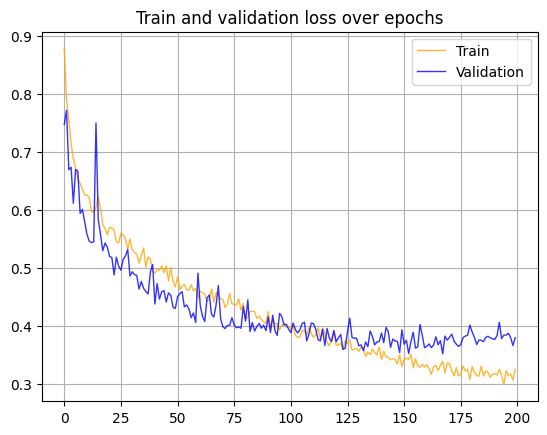

In [17]:
import seaborn as sns

sns.lineplot(
    data = epoch_history,
    x = [x for x in range(num_epochs)],
    y = epoch_history["Train Loss"],
    linewidth = 1,
    color = "orange",
    alpha = 0.8,
    label = "Train"
)

sns.lineplot(
    data = epoch_history,
    x = [x for x in range(num_epochs)],
    y = epoch_history["Validation Loss"],
    linewidth = 1,
    color = "blue",
    alpha = 0.8,
    label = "Validation"
)
plt.grid(True)
plt.title("Train and validation loss over epochs")
plt.show()

In [18]:
import numpy as np

def rle_encode(mask):
    pixels = mask.flatten(order='F')
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return ' '.join(str(x) for x in runs)

In [19]:
checkpoint_path = "/kaggle/input/models/mdabdulalhasib/a-sample-model-for-tgs-sault/pytorch/default/1/best_model (3).pth"
checkpoint = torch.load(checkpoint_path)

In [20]:
eval_model: AttentionUnet = AttentionUnet()
eval_model.to(device)
eval_model.load_state_dict(model.state_dict())

<All keys matched successfully>

In [21]:
test_root = "/kaggle/input/competitions/tgs-salt-identification-challenge/test.zip"
test_to = "/kaggle/working/unzipped_test"

os.makedirs(test_to, exist_ok = True)
with zipfile.ZipFile(test_root, "r") as zip_ref:
    zip_ref.extractall(test_to)

In [22]:
import pandas as pd
test_csv = pd.read_csv("/kaggle/input/competitions/tgs-salt-identification-challenge/sample_submission.csv")
test_ids = test_csv["id"].tolist()  
test_imgs = os.path.join(test_to , "images")
prediction_list = []

eval_model.eval()
with torch.no_grad():
    for img_id in tqdm(test_ids):
        img_path = os.path.join(test_imgs, img_id + ".png") 
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        img = test_tf(image=img)["image"].to(device)
        
        pred = eval_model(img.unsqueeze(0))
        prediction_list.append(pred.cpu().numpy())

100%|██████████| 18000/18000 [01:35<00:00, 188.02it/s]


In [23]:
import numpy as np
import pandas as pd

def resize_mask_nn(mask, target_size=(101, 101)):

    mask = (mask > 0.5).astype(np.uint8)
    mask = np.squeeze(mask)
    src_h, src_w = mask.shape
    tgt_h, tgt_w = target_size
    row_idx = (np.linspace(0, src_h - 1, tgt_h)).astype(int)
    col_idx = (np.linspace(0, src_w - 1, tgt_w)).astype(int)
    resized_mask = mask[np.ix_(row_idx, col_idx)]
    return resized_mask

def rle_encode(mask):

    pixels = mask.flatten(order='F')            
    pixels = np.concatenate([[0], pixels, [0]])  
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1  
    runs[1::2] -= runs[::2]                     
    return ' '.join(str(x) for x in runs)


submission_list = []

for img_id, pred in zip(test_ids, prediction_list):
    mask_101 = resize_mask_nn(pred)
    mask_101 = (mask_101 > 0.5).astype(np.uint8)
    
    if mask_101.sum() == 0:
        rle = "" 
    else:
        rle = rle_encode(mask_101)
    
    submission_list.append({"id": img_id, "rle_mask": rle})

submission_df = pd.DataFrame(submission_list)
submission_df.to_csv("submission.csv", index=False)
         
